<a href="https://colab.research.google.com/github/ngddung07/SC3021/blob/main/SC3021_Week_11_Joel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Week 11: Predictive Analytics (Linear Regression & Decision Trees)

Welcome to the tutorial. Today we are looking at predictive analytics. We will explore how to interpret linear regression models and how to build a basic decision tree classifier—all using Python and `scikit-learn`.

**Material developed by Joel Quek**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

## Part 1: Linear Regression in Healthcare

**The Scenario:** We are studying the relationship between running time per day $t$ (in minutes) and the number of calories burned $c$.

Based on our data, we obtain the following linear regression model:
$$C_{predicted} = 120 + 10t$$
with an $R^{2} = 0.74$.

**Discussion Questions:**
1. **What does the intercept mean?** T
2. **Does this reflect reality?**
3. **Should we use this for a medical treatment plan?**

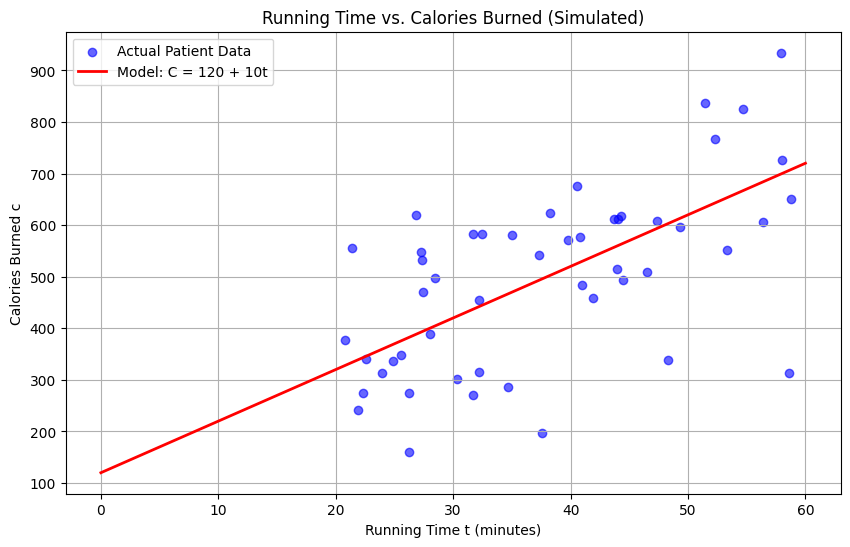

In [ ]:
# Let's visualize why an R^2 of 0.74 might be too messy for medical decisions.

# 1. Generate the theoretical model line (C = 120 + 10t)
t_values = np.linspace(0, 60, 100)
c_predicted = 120 + 10 * t_values

# 2. Simulate noisy real-world patient data
np.random.seed(42)
t_actual = np.random.uniform(20, 60, 50)
c_actual = 120 + 10 * t_actual + np.random.normal(0, 150, 50)

# 3. Plot it
plt.figure(figsize=(10, 6))
plt.scatter(t_actual, c_actual, color='blue', alpha=0.6, label='Actual Patient Data')
plt.plot(t_values, c_predicted, color='red', linewidth=2, label='Model: C = 120 + 10t')
plt.title('Running Time vs. Calories Burned (Simulated)')
plt.xlabel('Running Time t (minutes)')
plt.ylabel('Calories Burned c')
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Decision Tree Classifier

**The Scenario:** We want to predict if a customer will buy a product (`doesBuy`) based on their `PersonAge` and `PersonIncome`.

Instead of loading external CSV files, we will generate a realistic synthetic dataset right here in pandas, split it into training and testing sets, and train our model.

In [ ]:
# --- SECTION 2: DECISION TREE CLASSIFICATION (Q2) ---
print("\n--- Question 2: Decision Tree Implementation ---")

# 1. Create dummy data to simulate 'sales_train.csv' and 'sales_test.csv'
train_data = {
    'PersonAge': [25, 45, 35, 50, 23, 37],
    'PersonIncome': [30000, 80000, 45000, 120000, 25000, 60000],
    'Product': ['A', 'B', 'A', 'B', 'A', 'B'],
    'doesBuy': [0, 1, 0, 1, 0, 1]
}
test_data = {
    'PersonAge': [30, 48],
    'PersonIncome': [40000, 95000],
    'Product': ['A', 'B'],
    'doesBuy': [0, 1]
}

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


--- Question 2: Decision Tree Implementation ---


In [ ]:
train_df

,PersonAge,PersonIncome,Product,doesBuy
0,25,30000,A,0
1,45,80000,B,1
2,35,45000,A,0
3,50,120000,B,1
4,23,25000,A,0
5,37,60000,B,1


test_df

In [ ]:
test_df

,PersonAge,PersonIncome,Product,doesBuy
0,30,40000,A,0
1,48,95000,B,1


In [ ]:
# 2. Isolate Features and Labels (As per tutorial requirement)
X_train = train_df[['PersonAge', 'PersonIncome']]
y_train = train_df['doesBuy']
X_test = test_df[['PersonAge', 'PersonIncome']]
y_test = test_df['doesBuy']

In [ ]:
display(X_train)
display(y_train)
display(X_test)
display(y_test)

,PersonAge,PersonIncome
0,25,30000
1,45,80000
2,35,45000
3,50,120000
4,23,25000
5,37,60000


,doesBuy
0,0
1,1
2,0
3,1
4,0
5,1


,PersonAge,PersonIncome
0,30,40000
1,48,95000


,doesBuy
0,0
1,1


In [ ]:
dt_classifier = DecisionTreeClassifier(criterion='entropy')

In [ ]:
dt_classifier

DecisionTreeClassifier(criterion='entropy')

In [ ]:
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
dt_classifier.feature_importances_

array([0., 1.])

In [ ]:
# 4. Predict and Evaluate
predictions = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100}%")

Model Accuracy: 100.0%


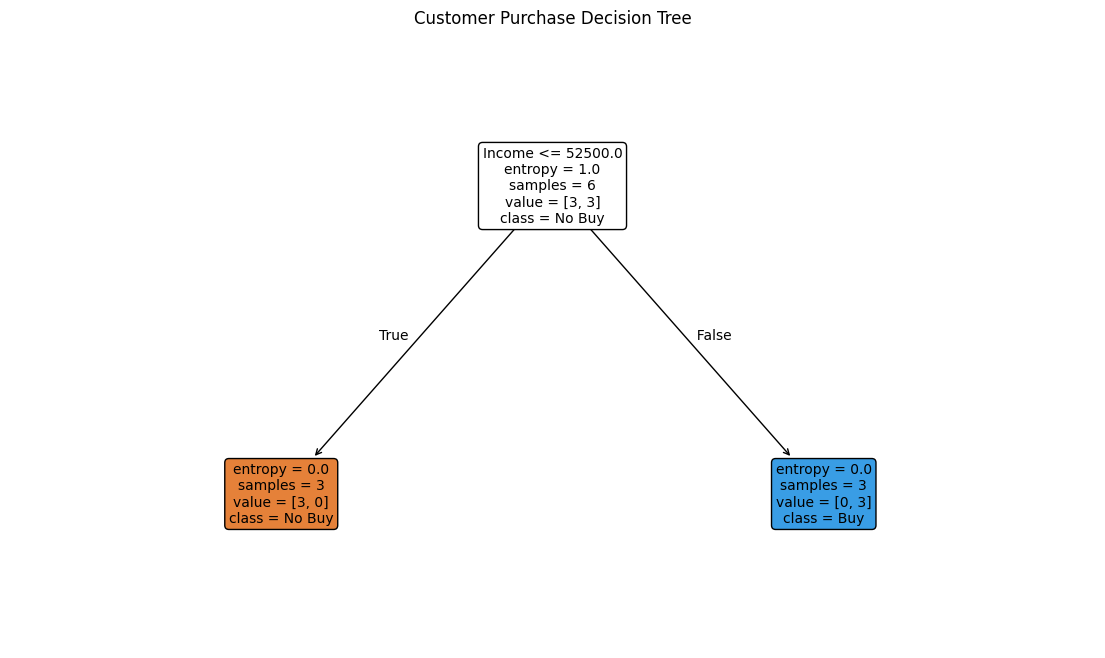

In [ ]:
# Step 6: Visualize the decision logic
plt.figure(figsize=(14, 8))
plot_tree(
    dt_classifier,
    feature_names=['Age', 'Income'],
    class_names=['No Buy', 'Buy'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Customer Purchase Decision Tree")
plt.show()



In the real world, datasets are messy, and models can easily "cheat." Today we will look at:
1. Building a larger dataset and using `train_test_split`.
2. **The Primary Key Trap:** Why IDs ruin models.
3. **Data Leakage:** When a feature gives away the answer.
4. **Overfitting:** Comparing a deep tree vs. a shallow tree.

In [ ]:
# --- Q2: CLASSIFICATION TRAPS (THE ID TRAP) ---
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Generate Dataset (1000 rows)
np.random.seed(42)
n_samples = 1000

customer_ids = np.arange(10000, 10000 + n_samples) # The Primary Key
age = np.random.randint(18, 70, n_samples)
income = np.random.randint(30000, 150000, n_samples)

# Rule: Older & richer buy more
buy_prob = (age > 40)*0.3 + (income > 80000)*0.4
does_buy = np.random.binomial(1, np.clip(buy_prob, 0.1, 0.9))

df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Age': age,
    'Income': income,
    'doesBuy': does_buy
})

# --- THE CRUCIAL STEP: TRAIN/TEST SPLIT ---
# We MUST split the data to show that memorizing IDs fails on NEW customers.
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# =====================================================================
# MODEL 1: THE CHEATING MODEL (Keeping CustomerID)
# =====================================================================
X_train_bad = df_train.drop('doesBuy', axis=1)
y_train_bad = df_train['doesBuy']
X_test_bad = df_test.drop('doesBuy', axis=1)
y_test_bad = df_test['doesBuy']

bad_tree = DecisionTreeClassifier(random_state=42)
bad_tree.fit(X_train_bad, y_train_bad)

print("--- MODEL 1: THE ID TRAP (Includes CustomerID) ---")
print(f"Training Accuracy: {accuracy_score(y_train_bad, bad_tree.predict(X_train_bad))*100:.1f}%")
print(f"Testing Accuracy:  {accuracy_score(y_test_bad, bad_tree.predict(X_test_bad))*100:.1f}%\n")

print("Feature Importances (Notice how CustomerID dominates):")
importances_bad = pd.DataFrame({'Feature': X_train_bad.columns, 'Importance': bad_tree.feature_importances_})
display(importances_bad.sort_values(by='Importance', ascending=False))


# =====================================================================
# MODEL 2: THE FAIR MODEL (Dropping CustomerID)
# =====================================================================
X_train_good = df_train.drop(['doesBuy', 'CustomerID'], axis=1)
y_train_good = df_train['doesBuy']
X_test_good = df_test.drop(['doesBuy', 'CustomerID'], axis=1)
y_test_good = df_test['doesBuy']

# We add max_depth=3 to stop standard overfitting and force it to learn general rules
good_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
good_tree.fit(X_train_good, y_train_good)

print("\n--- MODEL 2: THE FAIR MODEL (Dropped CustomerID) ---")
print(f"Training Accuracy: {accuracy_score(y_train_good, good_tree.predict(X_train_good))*100:.1f}%")
print(f"Testing Accuracy:  {accuracy_score(y_test_good, good_tree.predict(X_test_good))*100:.1f}%\n")

print("Feature Importances (Now it relies on real demographics):")
importances_good = pd.DataFrame({'Feature': X_train_good.columns, 'Importance': good_tree.feature_importances_})
display(importances_good.sort_values(by='Importance', ascending=False))

--- MODEL 1: THE ID TRAP (Includes CustomerID) ---
Training Accuracy: 100.0%
Testing Accuracy:  61.0%

Feature Importances (Notice how CustomerID dominates):


,Feature,Importance
2,Income,0.482694
0,CustomerID,0.265217
1,Age,0.252089



--- MODEL 2: THE FAIR MODEL (Dropped CustomerID) ---
Training Accuracy: 71.1%
Testing Accuracy:  69.0%

Feature Importances (Now it relies on real demographics):


,Feature,Importance
1,Income,0.720689
0,Age,0.279311


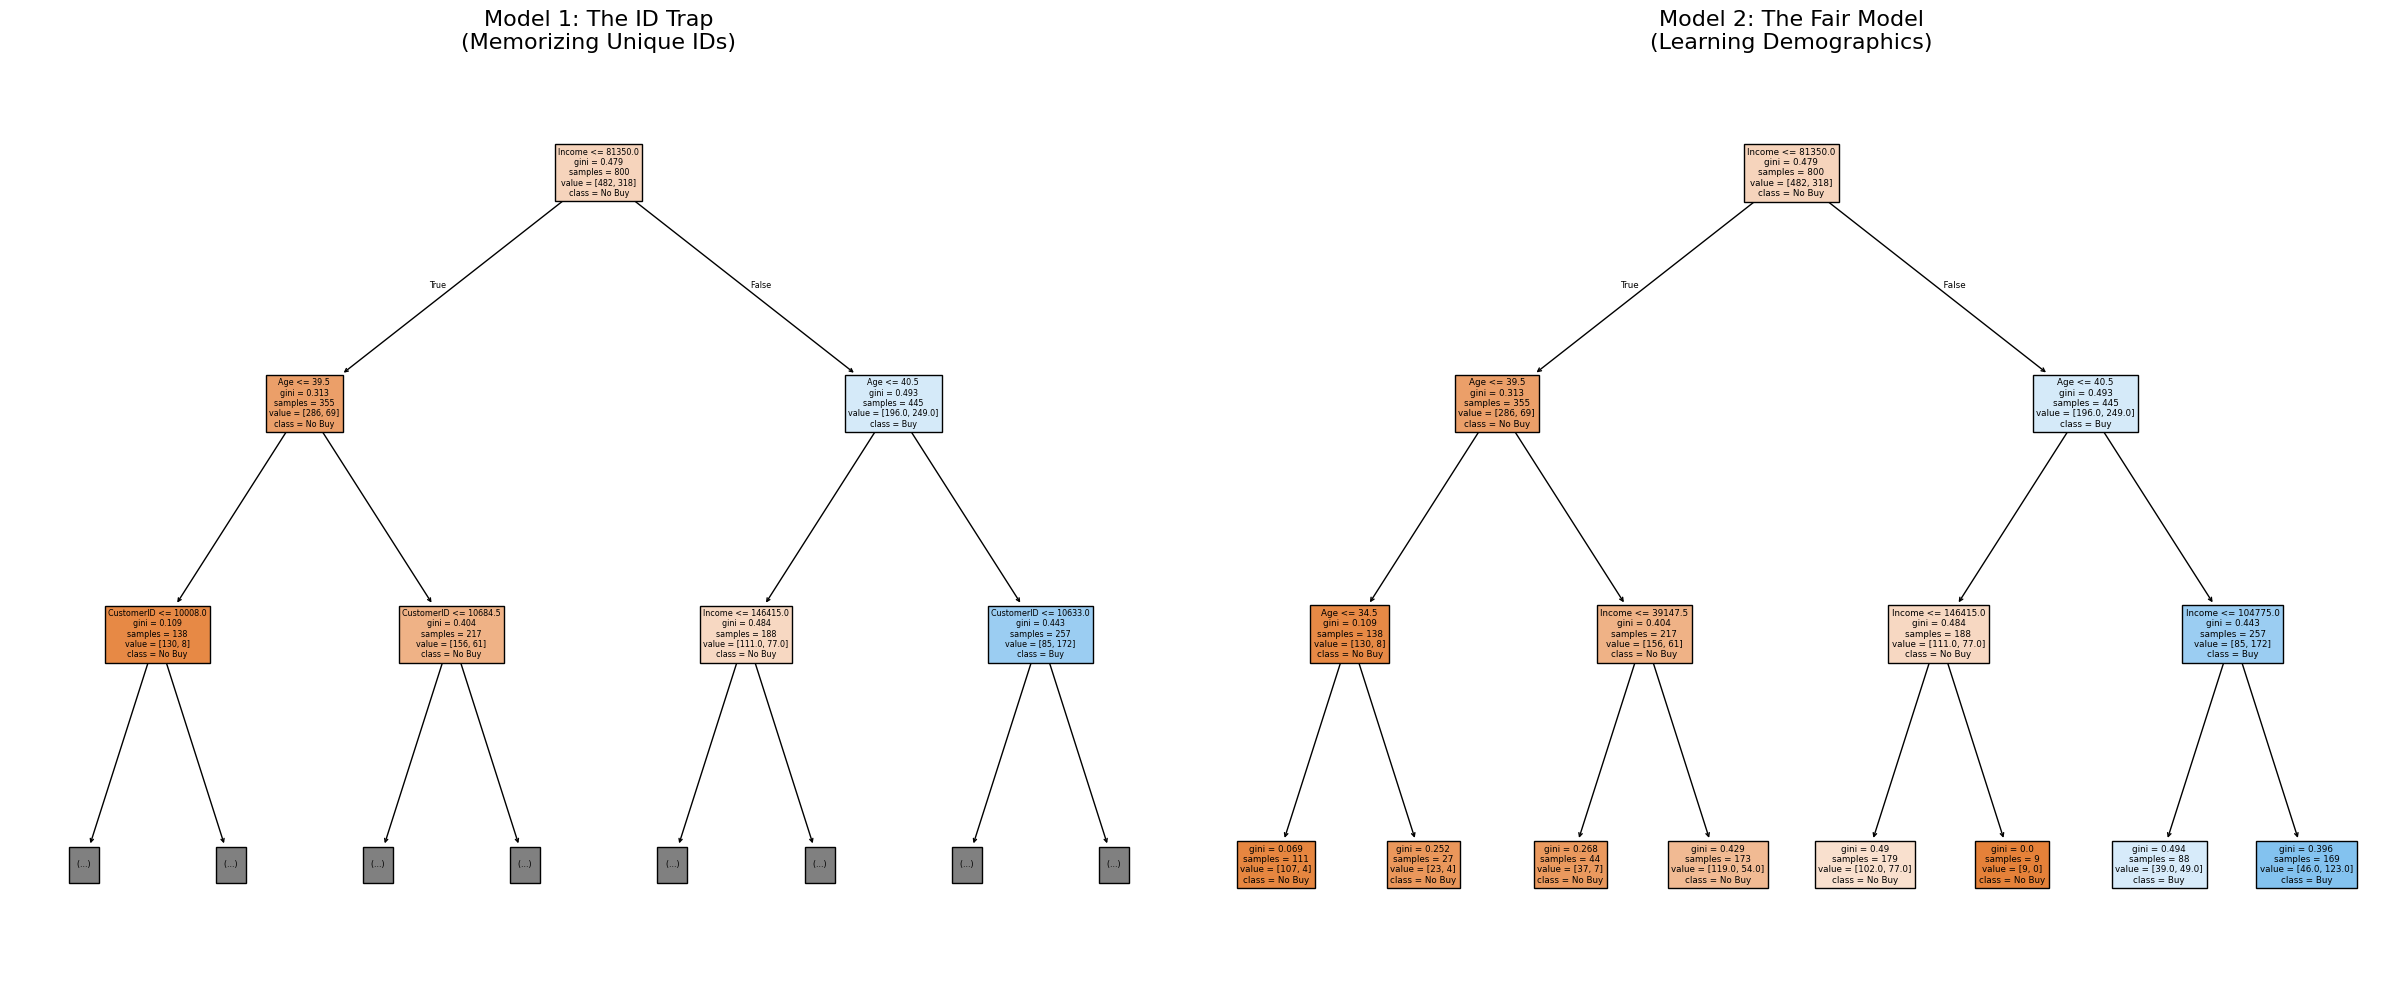

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Create a large figure to hold both visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# --- Plotting Model 1: The ID Trap ---
# We limit max_depth here just so the visualization is readable,
# but even at depth 3, you'll see it trying to split on CustomerID.
plot_tree(bad_tree,
          feature_names=list(X_train_bad.columns),
          class_names=['No Buy', 'Buy'],
          filled=True,
          max_depth=2,
          ax=ax1)
ax1.set_title("Model 1: The ID Trap\n(Memorizing Unique IDs)", fontsize=16)

# --- Plotting Model 2: The Fair Model ---
plot_tree(good_tree,
          feature_names=list(X_train_good.columns),
          class_names=['No Buy', 'Buy'],
          filled=True,
          ax=ax2)
ax2.set_title("Model 2: The Fair Model\n(Learning Demographics)", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Generate a Realistic, Noisy Dataset (1000 rows)
import numpy as np
import pandas as pd
np.random.seed(42)
n_samples = 1000

# Features
customer_ids = range(10000, 10000 + n_samples)
age = np.random.randint(18, 70, n_samples)
income = np.random.randint(30000, 150000, n_samples)
time_on_site = np.random.normal(15, 5, n_samples) # Minutes on website

# Create a realistic "doesBuy" target with some noise
# Older, wealthier people who spend more time on site are more likely to buy
buy_prob = (age > 40)*0.3 + (income > 80000)*0.4 + (time_on_site > 18)*0.2
buy_prob = np.clip(buy_prob, 0.1, 0.9)
does_buy = np.random.binomial(1, buy_prob)

# DATA LEAKAGE TRAP: "Initiated_Checkout" (Happens right before buying)
initiated_checkout = does_buy * np.random.binomial(1, 0.98) + (1 - does_buy) * np.random.binomial(1, 0.02)

df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Age': age,
    'Income': income,
    'TimeOnSite': time_on_site,
    'Initiated_Checkout': initiated_checkout, # The Leakage
    'doesBuy': does_buy
})

display(df.head())

,CustomerID,Age,Income,TimeOnSite,Initiated_Checkout,doesBuy
0,10000,56,135186,5.950205,0,0
1,10001,69,64674,19.825075,1,1
2,10002,46,65854,12.599341,0,0
3,10003,32,76271,15.639013,0,0
4,10004,60,103688,16.835511,1,1


In [ ]:
df

,CustomerID,Age,Income,TimeOnSite,Initiated_Checkout,doesBuy
0,10000,56,135186,5.950205,0,0
1,10001,69,64674,19.825075,1,1
2,10002,46,65854,12.599341,0,0
3,10003,32,76271,15.639013,0,0
4,10004,60,103688,16.835511,1,1
...,...,...,...,...,...,...
995,10995,60,37491,21.138604,1,1
996,10996,64,142831,9.682990,0,0
997,10997,62,80192,10.632952,1,1
998,10998,35,110395,8.692726,0,0


In [ ]:
# Train a naive model on ALL columns
X_bad = df.drop('doesBuy', axis=1)
y_bad = df['doesBuy']

bad_tree = DecisionTreeClassifier(random_state=42)
bad_tree.fit(X_bad, y_bad)

print(f"Naive Model Accuracy: {accuracy_score(y_bad, bad_tree.predict(X_bad)) * 100}%")

# Let's see what the model actually learned
importances = pd.DataFrame({'Feature': X_bad.columns, 'Importance': bad_tree.feature_importances_})
display(importances.sort_values(by='Importance', ascending=False))

Naive Model Accuracy: 100.0%


,Feature,Importance
4,Initiated_Checkout,1.0
0,CustomerID,0.0
1,Age,0.0
2,Income,0.0
3,TimeOnSite,0.0


**Why is this bad?**
1. **Data Leakage:** `Initiated_Checkout` basically *is* the target variable. If we already know they are at the checkout screen, we don't need a predictive model. We must drop it.
2. **Primary Keys:** The model might try to memorize `CustomerID`. IDs have no predictive power for *new* customers.

### The Proper Pipeline: Clean, Split, and Tune
Now we will drop the bad columns, split our data into Training (80%) and Testing (20%), and compare an **Overfitted Tree** against a **Well-Tuned Tree**.

In [ ]:
# Clean the features
X_clean = df.drop(['doesBuy', 'CustomerID', 'Initiated_Checkout'], axis=1)
y_clean = df['doesBuy']

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Model A: Let the tree grow infinitely deep (Overfitting)
tree_deep = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_deep.fit(X_train, y_train)

# Model B: Constrain the tree to find general patterns (Tuned)
tree_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_shallow.fit(X_train, y_train)

# Compare them side-by-side
print("--- DEEP TREE (Overfitted) ---")
print(f"Training Accuracy: {accuracy_score(y_train, tree_deep.predict(X_train))*100:.1f}%")
print(f"Testing Accuracy:  {accuracy_score(y_test, tree_deep.predict(X_test))*100:.1f}%\n")

print("--- SHALLOW TREE (Tuned) ---")
print(f"Training Accuracy: {accuracy_score(y_train, tree_shallow.predict(X_train))*100:.1f}%")
print(f"Testing Accuracy:  {accuracy_score(y_test, tree_shallow.predict(X_test))*100:.1f}%")

--- DEEP TREE (Overfitted) ---
Training Accuracy: 100.0%
Testing Accuracy:  66.0%

--- SHALLOW TREE (Tuned) ---
Training Accuracy: 70.9%
Testing Accuracy:  69.5%


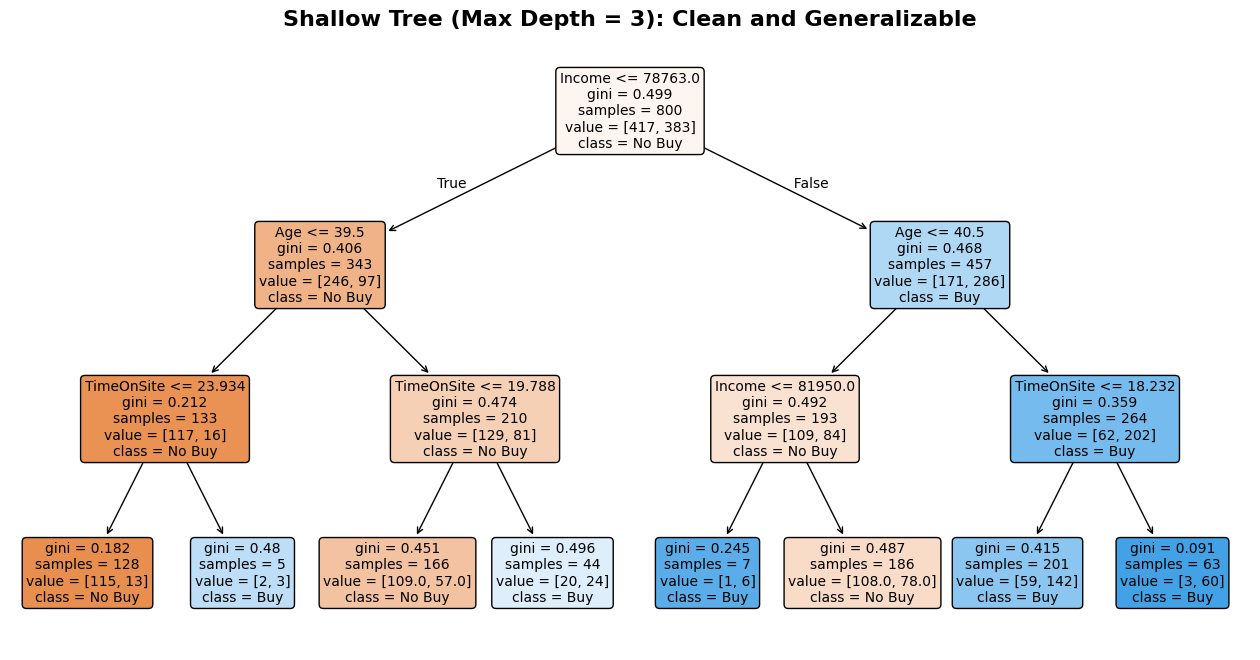

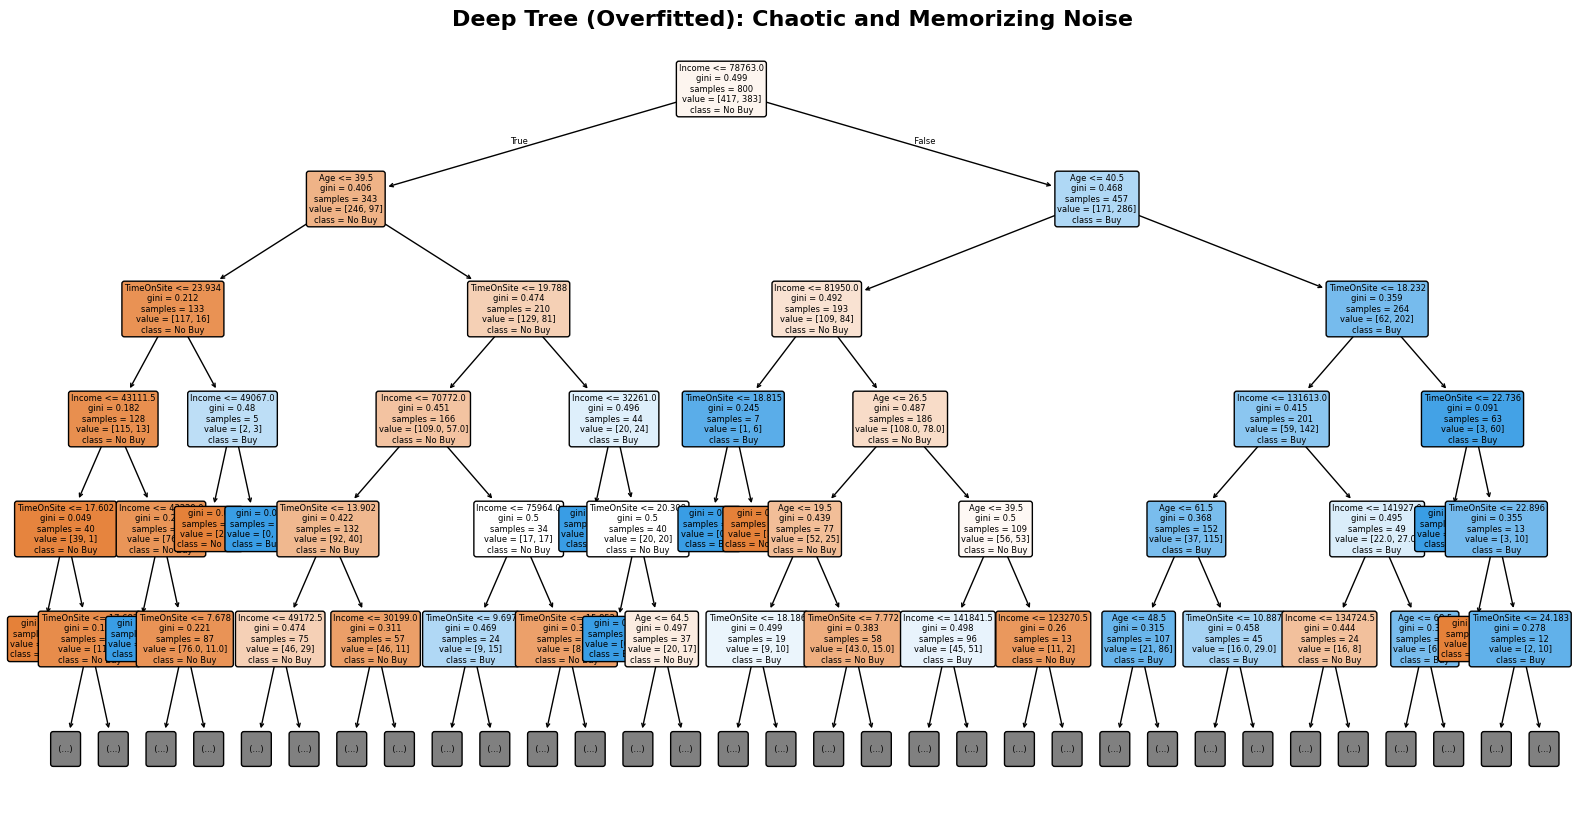

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Define the feature names and class names for the plots
feature_cols = X_clean.columns
class_labels = ['No Buy', 'Buy']

# --- Plot 1: The Shallow (Tuned) Tree ---
plt.figure(figsize=(16, 8))
plot_tree(
    tree_shallow,
    feature_names=feature_cols,
    class_names=class_labels,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Shallow Tree (Max Depth = 3): Clean and Generalizable", fontsize=16, fontweight='bold')
plt.show()

print("\n" + "="*80 + "\n")

# --- Plot 2: The Deep (Overfitted) Tree ---
# Note: We limit the plotted depth to 5 just so matplotlib doesn't crash,
# but it will still look incredibly messy!
plt.figure(figsize=(20, 10))
plot_tree(
    tree_deep,
    feature_names=feature_cols,
    class_names=class_labels,
    filled=True,
    rounded=True,
    max_depth=5, # Limiting the visual depth so it renders, but the tree itself is much deeper
    fontsize=6
)
plt.title("Deep Tree (Overfitted): Chaotic and Memorizing Noise", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import ipywidgets as widgets
from IPython.display import display

# 1. Generate a noisy, non-linear dataset (perfect for showing overfitting)
X, y = make_moons(n_samples=300, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Define the interactive plotting function
def plot_decision_boundary(max_depth):
    # Train the model
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X_train, y_train)

    # Calculate Accuracies
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    # Create a mesh grid to plot the decision boundaries
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotting
    plt.figure(figsize=(10, 6))

    # Draw the boundary regions
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Plot the Training points (Circles)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm',
                edgecolors='k', marker='o', s=60, label='Train Data')

    # Plot the Testing points (X's)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm',
                edgecolors='white', marker='X', s=60, label='Test Data', alpha=0.8)

    # Dynamic Title
    plt.title(f"Decision Tree Depth: {max_depth}\n"
              f"Training Accuracy: {train_acc*100:.1f}%  |  Testing Accuracy: {test_acc*100:.1f}%",
              fontsize=14, fontweight='bold')

    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# 3. Create the interactive slider
depth_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=20,
    step=1,
    description='Tree Depth:',
    continuous_update=False # Waits until you release the mouse to redraw, saving lag
)

# 4. Display the widget
widgets.interact(plot_decision_boundary, max_depth=depth_slider);

interactive(children=(IntSlider(value=1, continuous_update=False, description='Tree Depth:', max=20, min=1), O…

In [ ]:
# ---  LINEAR PROGRAMMING EXAMPLE(THE COFFEE ROASTER) ---
# Install the optimization library (PuLP is great for readable LP problems)
!pip install pulp
import pulp

# 1. Initialize the Model
# We want to MAXIMIZE our profit
model = pulp.LpProblem("Maximize_Cafe_Profit", pulp.LpMaximize)

# 2. Define the Decision Variables
# lowBound=0 ensures we can't make negative batches of coffee (Non-negativity constraint)
x = pulp.LpVariable('Morning_Roast_Batches', lowBound=0, cat='Continuous')
y = pulp.LpVariable('Smooth_Blend_Batches', lowBound=0, cat='Continuous')

# 3. Define the Objective Function (Profit)
# Morning Roast gives $4, Smooth Blend gives $3
model += 4 * x + 3 * y, "Total_Profit"

# 4. Define the Constraints (Inventory Limits)
# Arabica constraint: 40kg total
model += 2 * x + 1 * y <= 40, "Arabica_Limit"

# Robusta constraint: 50kg total
model += 1 * x + 2 * y <= 50, "Robusta_Limit"

# 5. Solve the math!
model.solve()

# --- Print the Results ---
print(f"Status: {pulp.LpStatus[model.status]}\n")

print("--- OPTIMAL RECIPE ---")
print(f"Make {x.varValue} batches of Morning Roast.")
print(f"Make {y.varValue} batches of Smooth Blend.\n")

print(f"MAXIMUM DAILY PROFIT: ${pulp.value(model.objective)}")

Status: Optimal

--- OPTIMAL RECIPE ---
Make 10.0 batches of Morning Roast.
Make 20.0 batches of Smooth Blend.

MAXIMUM DAILY PROFIT: $100.0
